# Semana 9: Inicialización, L2 y curvas

**Pregunta de trabajo.** Medir activaciones por capa y comparar regularización con la misma arquitectura y partición.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [2]:
def one_hot(y, num_classes):
    y = np.asarray(y, dtype=int)
    out = np.zeros((len(y), num_classes), dtype=float)
    out[np.arange(len(y)), y] = 1.0
    return out


def relu(Z):
    return np.maximum(0.0, Z)


def relu_derivative(Z):
    return (Z > 0).astype(float)


def softmax(Z):
    Z = np.asarray(Z, dtype=float)
    shifted = Z - np.max(Z, axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


def cross_entropy_loss(P, Y, eps=1e-12):
    P = np.clip(P, eps, 1.0)
    return float(-np.sum(Y * np.log(P)) / len(Y))


def init_parameters(n_features, n_hidden, n_classes, seed=42):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0.0, np.sqrt(2.0 / n_features), size=(n_features, n_hidden))
    b1 = np.zeros(n_hidden)
    W2 = rng.normal(0.0, np.sqrt(2.0 / n_hidden), size=(n_hidden, n_classes))
    b2 = np.zeros(n_classes)
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}


def forward_pass(X, params):
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    P = softmax(Z2)
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "P": P}
    return P, cache


def backward_pass(X, Y, cache, params, l2=0.0):
    n = len(X)
    P = cache["P"]
    A1 = cache["A1"]
    Z1 = cache["Z1"]
    W2 = params["W2"]

    dZ2 = (P - Y) / n
    dW2 = A1.T @ dZ2 + l2 * params["W2"]
    db2 = np.sum(dZ2, axis=0)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1 + l2 * params["W1"]
    db1 = np.sum(dZ1, axis=0)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}


def update_parameters(params, grads, lr):
    return {key: value - lr * grads[key] for key, value in params.items()}


def predict(X, params):
    P, _ = forward_pass(X, params)
    return np.argmax(P, axis=1).astype(int)


def train_mlp(X_train, y_train, X_val, y_val, n_hidden=32, lr=0.1, epochs=150, l2=0.0, seed=42):
    n_classes = int(np.max(y_train)) + 1
    Y_train = one_hot(y_train, n_classes)
    params = init_parameters(X_train.shape[1], n_hidden, n_classes, seed=seed)
    history = []
    for epoch in range(epochs):
        P, cache = forward_pass(X_train, params)
        loss = cross_entropy_loss(P, Y_train)
        if l2:
            loss += 0.5 * l2 * (np.sum(params["W1"] ** 2) + np.sum(params["W2"] ** 2))
        grads = backward_pass(X_train, Y_train, cache, params, l2=l2)
        params = update_parameters(params, grads, lr=lr)
        if epoch % 10 == 0 or epoch == epochs - 1:
            train_acc = accuracy_score(y_train, predict(X_train, params))
            val_acc = accuracy_score(y_val, predict(X_val, params))
            history.append({"epoch": epoch, "loss": loss, "train_acc": train_acc, "val_acc": val_acc})
    return params, pd.DataFrame(history)

In [3]:
digits = load_digits()
X = digits.data / 16.0
y = digits.target
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

## Comparación con y sin L2

In [4]:
_, hist_no_l2 = train_mlp(X_train[:700], y_train[:700], X_val[:250], y_val[:250], epochs=150, lr=0.15, l2=0.0, seed=3)
_, hist_l2 = train_mlp(X_train[:700], y_train[:700], X_val[:250], y_val[:250], epochs=150, lr=0.15, l2=1e-3, seed=3)
hist_no_l2['config'] = 'sin_l2'
hist_l2['config'] = 'l2'
pd.concat([hist_no_l2.tail(1), hist_l2.tail(1)])

,epoch,loss,train_acc,val_acc,config
15,149,0.284829,0.951429,0.908,sin_l2
15,149,0.354730,0.951429,0.908,l2


## Cierre
¿Qué configuración defendería y qué evidencia usaría?

## Inicialización y lectura de curvas

Antes de elegir configuración se inspeccionan activaciones y se conserva la convención L2 sin penalizar sesgos.

In [5]:
init_rows = []
rng = np.random.default_rng(2105)
for name, scale in [("cero", 0.0), ("pequeña", 0.01), ("He", np.sqrt(2 / X_train.shape[1])), ("grande", 1.0)]:
    W = np.zeros((X_train.shape[1], 32)) if scale == 0 else rng.normal(0, scale, size=(X_train.shape[1], 32))
    A = relu(X_train[:128] @ W)
    init_rows.append({"regla": name, "media": A.mean(), "std": A.std(), "fraccion_cero": (A == 0).mean()})
pd.DataFrame(init_rows)

,regla,media,std,fraccion_cero
0,cero,0.000000,0.000000,1.000000
1,pequeña,0.012106,0.019894,0.556152
2,He,0.226510,0.351608,0.552246
3,grande,1.309743,2.230577,0.560547


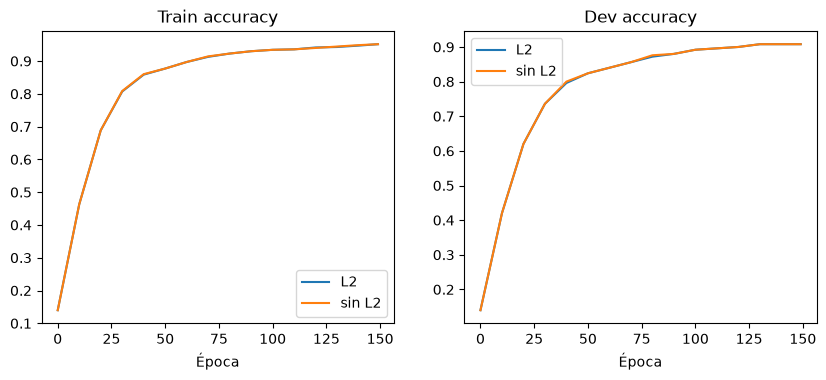

In [6]:
curves = pd.concat([hist_no_l2.assign(config="sin L2"), hist_l2.assign(config="L2")])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True)
for label, frame in curves.groupby("config"):
    axes[0].plot(frame["epoch"], frame["train_acc"], label=label)
    axes[1].plot(frame["epoch"], frame["val_acc"], label=label)
axes[0].set_title("Train accuracy"); axes[1].set_title("Dev accuracy")
for ax in axes: ax.legend(); ax.set_xlabel("Época")
plt.show()

In [7]:
P_probe, cache_probe = forward_pass(X_train[:12], init_parameters(64, 8, 10, seed=2))
Y_probe = one_hot(y_train[:12], 10)
probe_params = init_parameters(64, 8, 10, seed=2)
grads_no_l2 = backward_pass(X_train[:12], Y_probe, cache_probe, probe_params, l2=0.0)
grads_l2 = backward_pass(X_train[:12], Y_probe, cache_probe, probe_params, l2=0.1)
{
    "W1_addition_error": float(np.linalg.norm((grads_l2["W1"] - grads_no_l2["W1"]) - 0.1 * probe_params["W1"])),
    "b1_unchanged": bool(np.allclose(grads_l2["b1"], grads_no_l2["b1"])),
}

{'W1_addition_error': 8.950469808416669e-17, 'b1_unchanged': True}

In [8]:
summary = pd.concat([
    hist_no_l2.loc[[hist_no_l2["val_acc"].idxmax()]].assign(config="sin L2"),
    hist_l2.loc[[hist_l2["val_acc"].idxmax()]].assign(config="L2"),
])[['config', 'epoch', 'loss', 'train_acc', 'val_acc']]
summary

,config,epoch,loss,train_acc,val_acc
13,sin L2,130,0.325961,0.944286,0.908
13,L2,130,0.393841,0.942857,0.908
